In [1]:
from openpyxl import Workbook,load_workbook

# 新しいブック（Excelファイル）を作成
wb = Workbook()

# アクティブなワークシートを取得
ws = wb.active
ws.title = "成績"  # シート名を変更

# セルにデータを書き込み
ws["A1"] = "名前"
ws["B1"] = "点数"
ws["A2"] = "田中"
ws["B2"] = 92

# ファイルとして保存
wb.save("sample.xlsx")

In [2]:
# 作成したファイルを開く
wb = load_workbook("sample.xlsx")
ws = wb.active

# セルの内容を表示
print("名前:", ws["A2"].value)
print("点数:", ws["B2"].value)

名前: 田中
点数: 92


In [1]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import time

# Chromeを起動
driver = webdriver.Chrome()

# TeamSpartaの問い合わせフォームを開く
driver.get("https://www.sparta-co.jp/inquiry")
#画面の立ち上がりを待つ
time.sleep(1)

# iframe を取得
iframe = driver.find_element(By.TAG_NAME, "iframe")

# iframe に切り替え
driver.switch_to.frame(iframe)

# iframe 内の input を取得
inputs = driver.find_elements(By.TAG_NAME, "input")

# 最初の input 要素に名前を入力
inputs[1].send_keys("スパルタ 花子")
inputs[0].send_keys("スパルタ株式会社")

# 結果表示まで少し待つ
time.sleep(10)
driver.quit()

In [1]:
import requests
from bs4 import BeautifulSoup

# 取得したいWebページ
url = "https://www.sparta-co.jp"
res = requests.get(url)

res.encoding = res.apparent_encoding

# HTMLを解析
soup = BeautifulSoup(res.text, "html.parser")

# ページの<title>要素を表示
title = soup.title.text
print("ページのタイトル:", title)

ページのタイトル: スパルタ式の業務効率化DX研修 | TeamSparta


In [4]:
import requests
import csv

# サンプルAPIのURL
url = "https://b1cmc2eyo3.execute-api.ap-northeast-1.amazonaws.com/employees"

# Web APIにGETリクエストを送信し、レスポンスを受け取る
response = requests.get(url)

# レスポンスの中身（JSON形式）をPythonの辞書リストに変換
data = response.json()

# データの中身を確認（先頭の1件のみ表示）
print(data[0])

# CSVファイルとして保存
with open("posts.csv", "w", newline="", encoding="utf-8") as f:
    # CSVファイルに辞書形式のデータを書き込むwriterの準備、列の定義を指定
    writer = csv.DictWriter(f, fieldnames=data[0].keys())

    # ヘッダー行（列名）を書き込む
    writer.writeheader()

    # 実データの各行（辞書）をCSVとして書き込む
    writer.writerows(data)

{'index': 0, '社員ID': 'A001', '氏名': 'スパ田 太郎', '部署': '開発部', '日付': '2025-03-03', '勤務時間': None}


In [5]:
import requests
import csv

# サンプルAPIのURL
url = "https://b1cmc2eyo3.execute-api.ap-northeast-1.amazonaws.com/employees"

# Web APIにGETリクエストを送信し、レスポンスを受け取る
response = requests.get(url)

# レスポンスの中身（JSON形式）をPythonの辞書リストに変換
data = response.json()

# データの中身を確認（先頭の1件のみ表示）
print(data[0])

{'index': 0, '社員ID': 'A001', '氏名': 'スパ田 太郎', '部署': '開発部', '日付': '2025-03-03', '勤務時間': None}


In [6]:
# CSVファイルとして保存
with open("posts_2.csv", "w", newline="", encoding="utf-8") as f:
    # CSVファイルに辞書形式のデータを書き込むwriterの準備、列の定義を指定
    writer = csv.DictWriter(f, fieldnames=data[0].keys())

    # ヘッダー行（列名）を書き込む
    writer.writeheader()

    # 実データの各行（辞書）をCSVとして書き込む
    writer.writerows(data)

In [7]:
import pandas as pd

df=pd.read_csv("posts_2.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1710 entries, 0 to 1709
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   1710 non-null   int64  
 1   社員ID    1710 non-null   object 
 2   氏名      1710 non-null   object 
 3   部署      1710 non-null   object 
 4   日付      1710 non-null   object 
 5   勤務時間    1604 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 80.3+ KB


In [8]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1604 entries, 1 to 1709
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   1604 non-null   int64  
 1   社員ID    1604 non-null   object 
 2   氏名      1604 non-null   object 
 3   部署      1604 non-null   object 
 4   日付      1604 non-null   object 
 5   勤務時間    1604 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 87.7+ KB


In [13]:
or_over_0501 = df["日付"] >= "2025-05-01"
or_under_0531 = df["日付"] <= "2025-05-31"

only_may_df=df[(or_over_0501 & or_under_0531)]
only_may_df

,index,社員ID,氏名,部署,日付,勤務時間
43,43,A001,スパ田 太郎,開発部,2025-05-01,7.93
44,44,A001,スパ田 太郎,開発部,2025-05-02,8.05
45,45,A001,スパ田 太郎,開発部,2025-05-05,8.17
46,46,A001,スパ田 太郎,開発部,2025-05-06,8.75
47,47,A001,スパ田 太郎,開発部,2025-05-07,8.18
...,...,...,...,...,...,...
1705,1705,A030,チーム谷 悠斗,営業部,2025-05-14,8.47
1706,1706,A030,チーム谷 悠斗,営業部,2025-05-15,8.22
1707,1707,A030,チーム谷 悠斗,営業部,2025-05-16,8.45
1708,1708,A030,チーム谷 悠斗,営業部,2025-05-19,8.22


<Axes: xlabel='部署'>

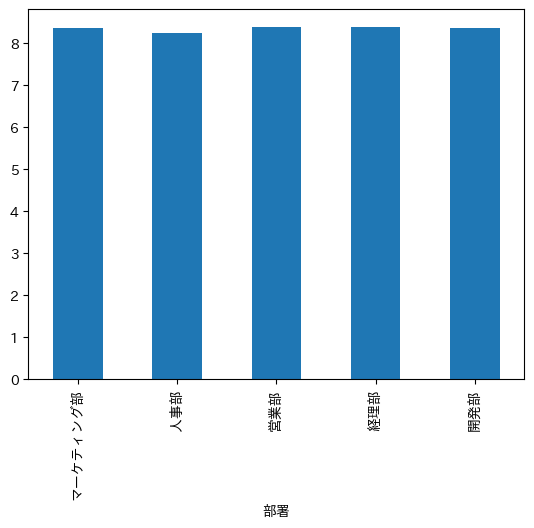

In [14]:
import japanize_matplotlib
only_may_df.groupby("部署")["勤務時間"].mean().plot(kind="bar")

{'index': 0, '社員ID': 'A001', '氏名': 'スパ田 太郎', '部署': '開発部', '日付': '2025-03-03', '勤務時間': None}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1710 entries, 0 to 1709
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   1710 non-null   int64  
 1   社員ID    1710 non-null   object 
 2   氏名      1710 non-null   object 
 3   部署      1710 non-null   object 
 4   日付      1710 non-null   object 
 5   勤務時間    1604 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 80.3+ KB


<Axes: xlabel='部署'>

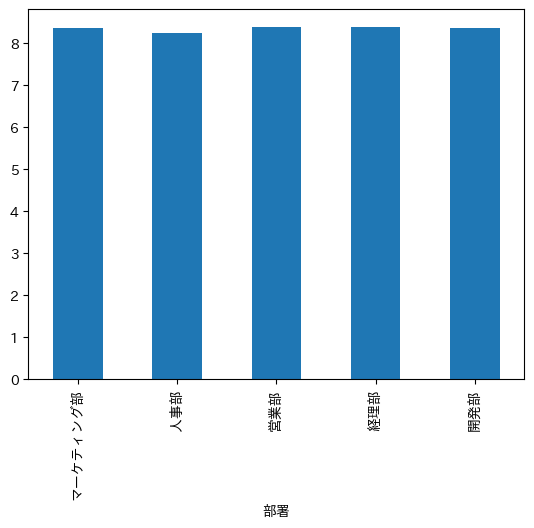

In [15]:
import requests
import csv
import pandas as pd
import japanize_matplotlib


# サンプルAPIのURL
url = "https://b1cmc2eyo3.execute-api.ap-northeast-1.amazonaws.com/employees"

# Web APIにGETリクエストを送信し、レスポンスを受け取る
response = requests.get(url)

# レスポンスの中身（JSON形式）をPythonの辞書リストに変換
data = response.json()

# データの中身を確認（先頭の1件のみ表示）
print(data[0])

with open("posts_2.csv", "w", newline="", encoding="utf-8") as f:
    # CSVファイルに辞書形式のデータを書き込むwriterの準備、列の定義を指定
    writer = csv.DictWriter(f, fieldnames=data[0].keys())

    # ヘッダー行（列名）を書き込む
    writer.writeheader()

    # 実データの各行（辞書）をCSVとして書き込む
    writer.writerows(data)

df=pd.read_csv("posts_2.csv")
df.info()

or_over_0501 = df["日付"] >= "2025-05-01"
or_under_0531 = df["日付"] <= "2025-05-31"

only_may_df=df[(or_over_0501 & or_under_0531)]

only_may_df.groupby("部署")["勤務時間"].mean().plot(kind="bar")